# Global Suicide Rates & Socioeconomic Factors

## Project Overview

This project analyzes global suicide rates from 2000 to 2021 across 185 countries. The goal is to explore trends in suicide rates over time and examine how factors such as sex, GDP per capita, and population relate to suicide rates.

### Questions I Want to Answer

1. How have suicide rates changed from 2000 to 2021?
2. How do suicide rates differ between males and females?
3. Which countries have the highest and lowest suicide rates?
4. Is there a relationship between GDP per capita and suicide rates?
5. What limitations should be considered when interpreting these relationships?

## 1. Import Libraries and Load the Dataset

In [39]:
# Import libraries 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [40]:
df = pd.read_csv("/kaggle/input/datasets/samartalwar/global-suicide-rates-and-socioeconomic-indicators/global_suicide_rates_real_who_worldbank.csv")

df.head()

,country,country_code,year,sex,age_bracket,suicide_rate_per_100k,generation,gdp_usd,gdp_per_capita_usd,total_country_population
0,Afghanistan,AFG,2000,both,all_ages,4.36,All Cohorts,3.521418e+09,174.930991,20130327.0
1,Afghanistan,AFG,2000,female,all_ages,2.91,All Cohorts,3.521418e+09,174.930991,20130327.0
2,Afghanistan,AFG,2000,male,all_ages,5.79,All Cohorts,3.521418e+09,174.930991,20130327.0
3,Afghanistan,AFG,2001,both,all_ages,4.38,All Cohorts,2.813572e+09,138.706822,20284307.0
4,Afghanistan,AFG,2001,female,all_ages,2.92,All Cohorts,2.813572e+09,138.706822,20284307.0


## 2. Data Overview & Quality Assessment

Before beginning the analysis, I first examined the structure and quality of the dataset.

In [41]:
df.shape

(18315, 10)

In [42]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18315 entries, 0 to 18314
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   country                   18315 non-null  object 
 1   country_code              18315 non-null  object 
 2   year                      18315 non-null  int64  
 3   sex                       18315 non-null  object 
 4   age_bracket               18315 non-null  object 
 5   suicide_rate_per_100k     18315 non-null  float64
 6   generation                18315 non-null  object 
 7   gdp_usd                   18000 non-null  float64
 8   gdp_per_capita_usd        18000 non-null  float64
 9   total_country_population  18315 non-null  float64
dtypes: float64(4), int64(1), object(5)
memory usage: 1.4+ MB


In [43]:
df.isnull().sum()

country                       0
country_code                  0
year                          0
sex                           0
age_bracket                   0
suicide_rate_per_100k         0
generation                    0
gdp_usd                     315
gdp_per_capita_usd          315
total_country_population      0
dtype: int64

In [44]:
df.duplicated().sum()

np.int64(0)

In [45]:
overall_df = df[
    (df["sex"] == "both") &
    (df["age_bracket"] == "all_ages")
]

### Data Quality Findings

The dataset contains 18,315 rows and 10 columns. No duplicate rows were found. However, 315 missing values were found in both the GDP and GDP per capita columns.

The dataset also contains multiple sex and age categories. The age groups overlap, so using every row together could lead to inaccurate results. For the overall analysis, I created a separate dataset using only the "both" sex category and "all_ages" age bracket.

In [46]:
df["sex"].unique()
df["age_bracket"].unique()

array(['all_ages', '10-19', '15-19', '15-29', '20-29', '30-39', '30-49',
       '40-49', '50-59', '50-69', '60-69', '70plus'], dtype=object)

In [47]:
overall_df.shape

(4070, 10)

### Verifying the Filtered Dataset

To ensure the filtering was successful, I checked the unique values for the sex and age bracket columns.

In [48]:
print(overall_df["sex"].unique())
print(overall_df["age_bracket"].unique())

['both']
['all_ages']


## 3. Exploratory Data Analysis

### Global Suicide Rate Trends Over Time

The first part of the analysis examines how suicide rates have changed between 2000 and 2021.

In [49]:
overall_df = df[
    (df["sex"] == "both") &
    (df["age_bracket"] == "all_ages")
].copy()

In [50]:
overall_df["weighted_rate"] = (
    overall_df["suicide_rate_per_100k"] *
    overall_df["total_country_population"]
)

In [51]:
overall_df[["year", "suicide_rate_per_100k", "total_country_population", "weighted_rate"]].head()

,year,suicide_rate_per_100k,total_country_population,weighted_rate
0,2000,4.36,20130327.0,87768225.72
3,2001,4.38,20284307.0,88845264.66
6,2002,4.26,21378117.0,91070778.42
9,2003,4.24,22733049.0,96388127.76
12,2004,4.23,23560654.0,99661566.42


In [52]:
global_trend = overall_df.groupby("year").agg(
    weighted_sum=("weighted_rate", "sum"),
    total_population=("total_country_population", "sum")
)

global_trend["global_suicide_rate"] = (
    global_trend["weighted_sum"] /
    global_trend["total_population"]
)

global_trend.head()

,weighted_sum,total_population,global_suicide_rate
year,,,
2000,7.665055e+10,6.128461e+09,12.507309
2001,7.556032e+10,6.211421e+09,12.164740
2002,7.617554e+10,6.293673e+09,12.103512
2003,7.681684e+10,6.375744e+09,12.048294
2004,7.719915e+10,6.458574e+09,11.952971


#### Global Trend Visualization

To visualize the change in global suicide rates over time, I plotted the population-weighted suicide rate for each year.

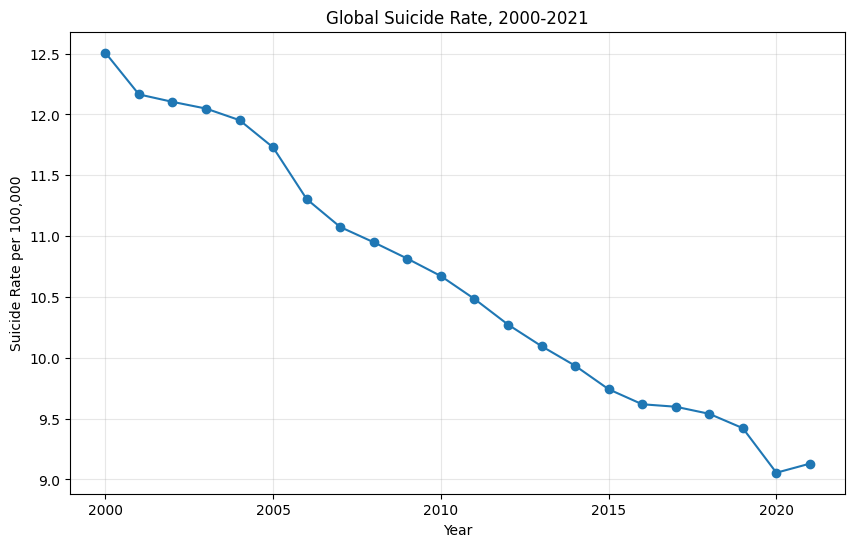

In [53]:
plt.figure(figsize=(10, 6))

plt.plot(
    global_trend.index,
    global_trend["global_suicide_rate"],
    marker="o"
)

plt.title("Global Suicide Rate, 2000-2021")
plt.xlabel("Year")
plt.ylabel("Suicide Rate per 100,000")
plt.grid(alpha=0.3)

plt.show()

#### Key Finding

The global suicide rate shows an overall downward trend between 2000 and 2021. The population-weighted rate decreased from approximately 12.51 per 100,000 people in 2000 to 9.13 per 100,000 in 2021, representing a decrease of about 27%.

In [54]:
rate_2000 = global_trend.loc[2000, "global_suicide_rate"]
rate_2021 = global_trend.loc[2021, "global_suicide_rate"]

print(rate_2000)
print(rate_2021)

12.50730911873721
9.130230088130633


In [55]:
percent_decrease = ((rate_2000 - rate_2021) / rate_2000) * 100

print(percent_decrease)

27.00084405483648


### Suicide Rates by Sex

The next part of the analysis compares suicide rates between males and females. To avoid including the combined "both" category, the data was filtered to include only male and female records.

In [56]:
sex_df = df[
    (df["sex"].isin(["male", "female"])) &
    (df["age_bracket"] == "all_ages")
].copy()

In [57]:
print(sex_df["sex"].unique())
print(sex_df["age_bracket"].unique())

['female' 'male']
['all_ages']


Replacing overall_df with sex_df to find the suicide rate separately for males and females.

In [58]:
sex_df["weighted_rate"] = (
    sex_df["suicide_rate_per_100k"] *
    sex_df["total_country_population"]
)

In [59]:
sex_summary = sex_df.groupby("sex").agg(
    weighted_sum=("weighted_rate", "sum"),
    total_population=("total_country_population", "sum")
)

sex_summary

,weighted_sum,total_population
sex,,
female,1.089599e+12,1.543101e+11
male,2.190394e+12,1.543101e+11


In [60]:
sex_summary["weighted_suicide_rate"] = (
    sex_summary["weighted_sum"] /
    sex_summary["total_population"]
)

sex_summary

,weighted_sum,total_population,weighted_suicide_rate
sex,,,
female,1.089599e+12,1.543101e+11,7.061100
male,2.190394e+12,1.543101e+11,14.194753


#### Key Finding

Male suicide rates were substantially higher than female suicide rates in the dataset. Using country population as a weighting factor, the average male suicide rate was approximately 14.19 per 100,000 compared with 7.06 per 100,000 for females. This means the male rate was about twice the female rate.

#### Male vs. Female Suicide Rates

The following chart compares the population-weighted suicide rates for males and females across the countries represented in the dataset.

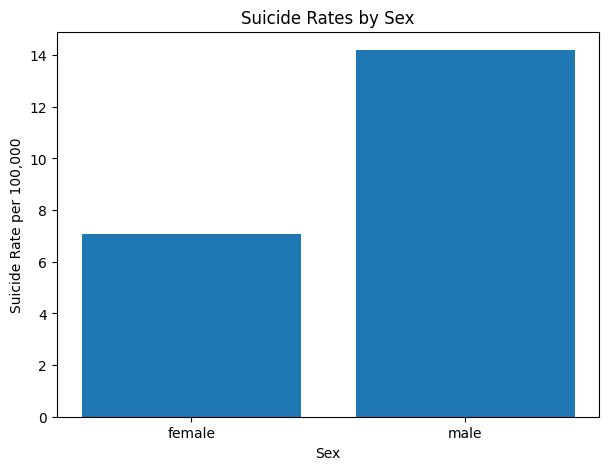

In [61]:
plt.figure(figsize=(7, 5))

plt.bar(
    sex_summary.index,
    sex_summary["weighted_suicide_rate"]
)

plt.title("Suicide Rates by Sex")
plt.xlabel("Sex")
plt.ylabel("Suicide Rate per 100,000")

plt.show()

### Suicide Rates by Country

The next part of the analysis examines differences in suicide rates between countries. I will identify the countries with the highest and lowest suicide rates over the period covered by the dataset.

In [62]:
country_rates = overall_df.groupby("country")["suicide_rate_per_100k"].mean()

In [63]:
country_rates.head()

country
Afghanistan            3.811364
Albania                4.985909
Algeria                2.757273
Angola                 7.584545
Antigua and Barbuda    0.672727
Name: suicide_rate_per_100k, dtype: float64

In [64]:
country_rates.sort_values(ascending=True)

country
Palestine, State of       0.654091
Antigua and Barbuda       0.672727
Syrian Arab Republic      0.687273
Lebanon                   0.825000
Sao Tome and Principe     0.862273
                           ...    
Korea, Republic of       27.279545
Guyana                   29.233182
Belarus                  30.025909
Russian Federation       36.574091
Lithuania                36.786818
Name: suicide_rate_per_100k, Length: 185, dtype: float64

In [65]:
top_10_countries = country_rates.sort_values(ascending=False).head(10)

top_10_countries

country
Lithuania             36.786818
Russian Federation    36.574091
Belarus               30.025909
Guyana                29.233182
Korea, Republic of    27.279545
Kazakhstan            27.055455
Ukraine               26.547273
Suriname              24.120909
Latvia                23.721818
Hungary               23.538636
Name: suicide_rate_per_100k, dtype: float64

#### Countries With the Highest Average Suicide Rates

To compare suicide rates across countries, I calculated the mean suicide rate for each country across the years available in the dataset. The ten countries with the highest average rates are visualized below.

<Axes: ylabel='country'>

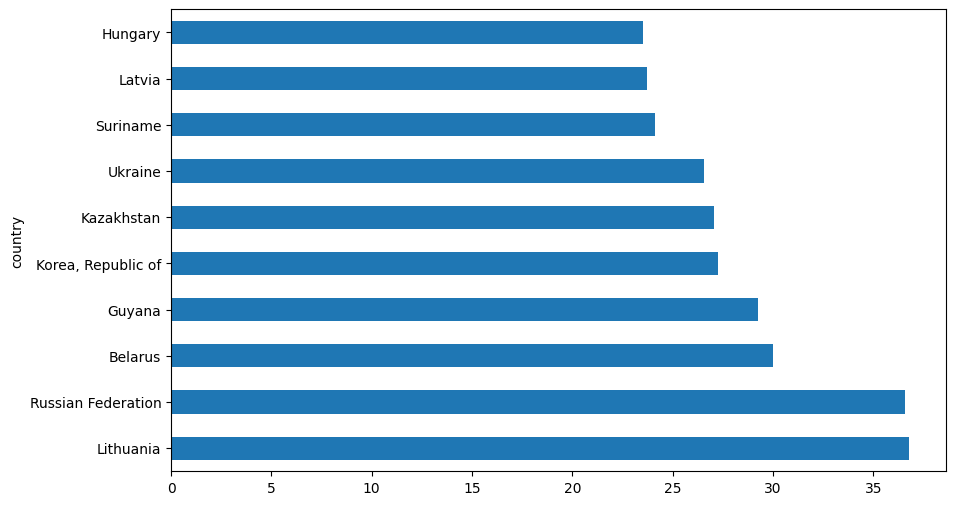

In [66]:
top_10_countries.plot(kind="barh", figsize=(10, 6))

#### Rearranged the graph so the highest will be on top* 

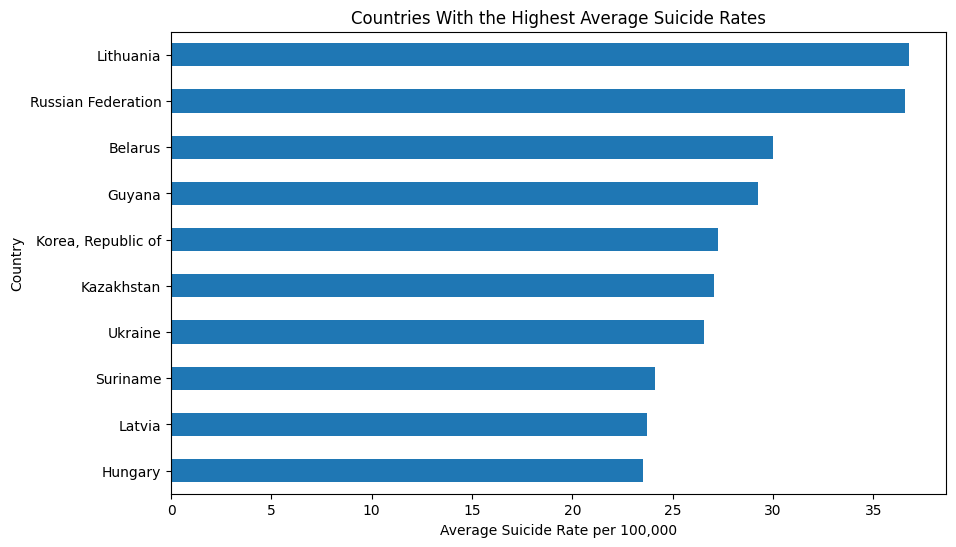

In [67]:
top_10_countries.sort_values(ascending=True).plot(
    kind="barh",
    figsize=(10, 6)
)

plt.title("Countries With the Highest Average Suicide Rates")
plt.xlabel("Average Suicide Rate per 100,000")
plt.ylabel("Country")

plt.show()

#### Key Finding

Lithuania had the highest average suicide rate among the countries in the dataset at approximately 36.79 per 100,000, followed closely by the Russian Federation at 36.57. Several of the countries with the highest average rates were located in Eastern Europe and Central Asia.

In [68]:
bottom_10_countries = country_rates.sort_values(ascending=True).head(10)

bottom_10_countries

country
Palestine, State of      0.654091
Antigua and Barbuda      0.672727
Syrian Arab Republic     0.687273
Lebanon                  0.825000
Sao Tome and Principe    0.862273
Egypt                    0.922273
Jordan                   1.191364
Peru                     1.405000
Jamaica                  1.416818
Saudi Arabia             1.533182
Name: suicide_rate_per_100k, dtype: float64

#### Lowest Average Rates

The lowest average suicide rates in the dataset were observed in Palestine, Antigua and Barbuda, and the Syrian Arab Republic, each averaging below 0.70 per 100,000 across the years represented in the dataset. These results should be interpreted carefully because differences in reporting practices and data availability between countries may affect international comparisons.

## 4. GDP and Suicide Rate

The next analysis examines the relationship between GDP per capita and suicide rates. Because some observations are missing GDP information, rows with missing GDP per capita values will be excluded from this specific analysis.

In [69]:
gdp_df = overall_df.dropna(subset=["gdp_per_capita_usd"]).copy()

In [70]:
gdp_df.shape

(4020, 11)

In [71]:
gdp_df["gdp_per_capita_usd"].isna().sum()    # verify missing values are gone

np.int64(0)

In [72]:
gdp_df["gdp_per_capita_usd"].describe()

count      4020.000000
mean      11794.263306
std       17881.845942
min         109.593814
25%        1243.963514
50%        4076.575428
75%       13647.191508
max      134965.815442
Name: gdp_per_capita_usd, dtype: float64

### GDP per Capita vs. Suicide Rate

To examine the relationship between economic conditions and suicide rates, I used a scatter plot comparing GDP per capita with the reported suicide rate. Each point represents an observation in the dataset.

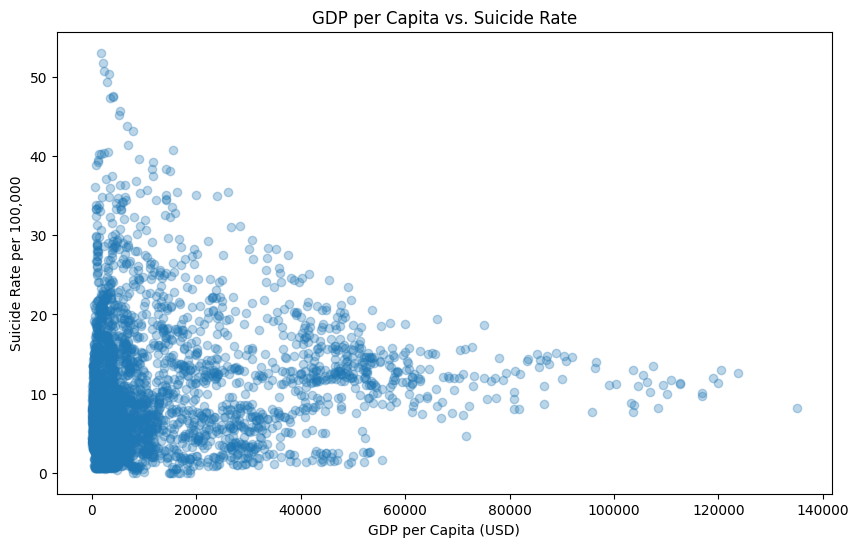

In [73]:
plt.figure(figsize=(10, 6))

plt.scatter(
    gdp_df["gdp_per_capita_usd"],
    gdp_df["suicide_rate_per_100k"],
    alpha=0.3
)

plt.title("GDP per Capita vs. Suicide Rate")
plt.xlabel("GDP per Capita (USD)")
plt.ylabel("Suicide Rate per 100,000")

plt.show()

#### Correlation Analysis

The scatter plot suggests a negative relationship between GDP per capita and suicide rate. To quantify the strength and direction of this relationship, I calculated the Pearson correlation coefficient.

In [74]:
correlation = gdp_df[
    ["gdp_per_capita_usd", "suicide_rate_per_100k"]
].corr().iloc[0, 1]

print(correlation)

0.15038912006179214


#### Correlation Finding

The Pearson correlation coefficient between GDP per capita and suicide rate was approximately 0.15. This indicates a weak positive linear relationship in this dataset. Although the scatter plot may appear to show some downward pattern, the correlation calculation suggests that GDP per capita alone has only a weak linear association with the reported suicide rate.

## 5. Key Takeaways and Limitations

### Key Takeaways

- The population-weighted global suicide rate decreased from approximately 12.51 per 100,000 in 2000 to 9.13 per 100,000 in 2021, a decrease of about 27%.
- The reported male suicide rate was higher than the female rate in the dataset.
- Lithuania and the Russian Federation had the highest average reported suicide rates among the countries analyzed.
- The Pearson correlation between GDP per capita and suicide rate was approximately 0.15, indicating a weak positive linear relationship.

### Limitations

This analysis has several limitations. The dataset contains missing GDP information, so those observations were excluded from the GDP analysis. The dataset also contains overlapping age brackets, so the main analysis was restricted to the "all_ages" category. In addition, country-level suicide statistics can be affected by differences in reporting practices, data availability, and measurement between countries. Finally, correlation does not establish that GDP causes changes in suicide rates.

## Tools Used

- Python
- Pandas
- NumPy
- Matplotlib
- Kaggle Notebook

## Dataset

Global Suicide Rates and Socioeconomic Indicators